NAME : MOHD RAZA, ROLL NOT : 33, SECTION : B  


LAB SHEET : 01  

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Loading the Titanic Survival Dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

display(df.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Step 3: Descriptive Statistics
We will now calculate mean, median, mode, variance, and standard deviation for key numerical features like `Age`, `MonthlyIncome`, and `TotalWorkingYears`.

In [ ]:
numerical_features = ['Age', 'Fare', 'Pclass', 'SibSp', 'Parch']
# Drop rows with NaN in Age for statistical calculation
stats_df = df[numerical_features].dropna()

stats_summary = stats_df.agg(['mean', 'median', 'std', 'var'])
modes = stats_df.mode().iloc[0]
stats_summary.loc['mode'] = modes

display(stats_summary)

,Age,Fare,Pclass,SibSp,Parch
mean,29.699118,34.694514,2.236695,0.512605,0.431373
median,28.000000,15.741700,2.000000,0.000000,0.000000
std,14.526497,52.918930,0.838250,0.929783,0.853289
var,211.019125,2800.413100,0.702663,0.864497,0.728103
mode,24.000000,13.000000,3.000000,0.000000,0.000000


### Step 4: Correlation Analysis
Calculating the Pearson correlation coefficient and visualizing the correlation matrix for numerical features.

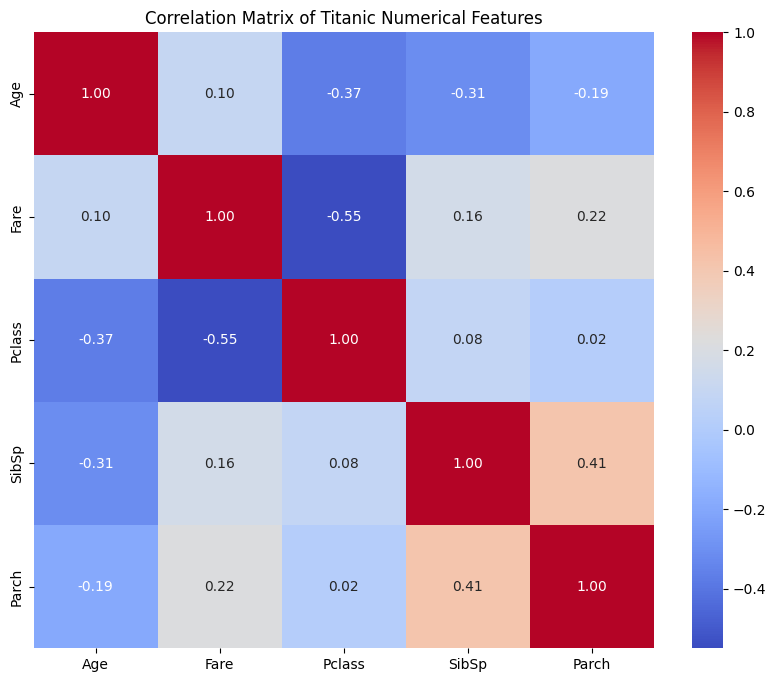

Pearson Correlation Coefficients:


,Age,Fare,Pclass,SibSp,Parch
Age,1.000000,0.096067,-0.369226,-0.308247,-0.189119
Fare,0.096067,1.000000,-0.549500,0.159651,0.216225
Pclass,-0.369226,-0.549500,1.000000,0.083081,0.018443
SibSp,-0.308247,0.159651,0.083081,1.000000,0.414838
Parch,-0.189119,0.216225,0.018443,0.414838,1.000000


In [ ]:
plt.figure(figsize=(10, 8))
numerical_features = ['Age', 'Fare', 'Pclass', 'SibSp', 'Parch']
correlation_matrix = df[numerical_features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Titanic Numerical Features')
plt.show()

print("Pearson Correlation Coefficients:")
display(correlation_matrix)

### Step 5 & 6: Hypothesis Testing (Independent t-test)
**Business Problem:** Is there a significant difference in monthly income between employees who leave the company and those who stay?

**Hypotheses:**
- **Null Hypothesis (H₀):** There is no significant difference in the mean monthly income between employees who leave and those who stay.
- **Alternative Hypothesis (H₁):** There is a significant difference in the mean monthly income between employees who leave and those who stay.

In [ ]:
# Business Problem: Is there a significant difference in Fare between those who survived and those who did not?
fare_survived = df[df['Survived'] == 1]['Fare']
fare_not_survived = df[df['Survived'] == 0]['Fare']

# Perform Independent Sample t-test
t_stat, p_val = stats.ttest_ind(fare_survived, fare_not_survived, equal_var=False)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4e}")

alpha = 0.05
if p_val < alpha:
    print("Result: Reject the Null Hypothesis (Significant difference in Fare found)")
else:
    print("Result: Fail to reject the Null Hypothesis")

T-statistic: 6.8391
P-value: 2.6993e-11
Result: Reject the Null Hypothesis (Significant difference in Fare found)


### Step 7: One-Way ANOVA
We test if there is a statistically significant difference in `Fare` across different `Pclass` (Passenger Class) categories.

In [ ]:
# Preparing data for ANOVA
model_anova = ols('Fare ~ C(Pclass)', data=df).fit()
anova_table = sm.stats.anova_lm(model_anova, typ=2)

print("One-Way ANOVA Results for Fare across Passenger Classes:")
display(anova_table)

# Interpretation
# Use .iloc[0] to avoid FutureWarning for positional indexing
p_val_anova = anova_table['PR(>F)'].iloc[0]
if p_val_anova < 0.05:
    print(f"Result: Significant difference found (p = {p_val_anova:.4e})")
else:
    print(f"Result: No significant difference found (p = {p_val_anova:.4f})")

One-Way ANOVA Results for Fare across Passenger Classes:


,sum_sq,df,F,PR(>F)
C(Pclass),7.760301e+05,2.0,242.344157,1.031376e-84
Residual,1.421769e+06,888.0,NaN,NaN


Result: Significant difference found (p = 1.0314e-84)


### Step 8 & 9: Simple Linear Regression
We will analyze the relationship between `Age` (Independent Variable) and `Fare` (Dependent Variable) for passengers.

                            OLS Regression Results                            
Dep. Variable:                   Fare   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     6.632
Date:                Mon, 24 Aug 2026   Prob (F-statistic):             0.0102
Time:                        08:19:08   Log-Likelihood:                -3843.0
No. Observations:                 714   AIC:                             7690.
Df Residuals:                     712   BIC:                             7699.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         24.3009      4.492      5.410      0.0

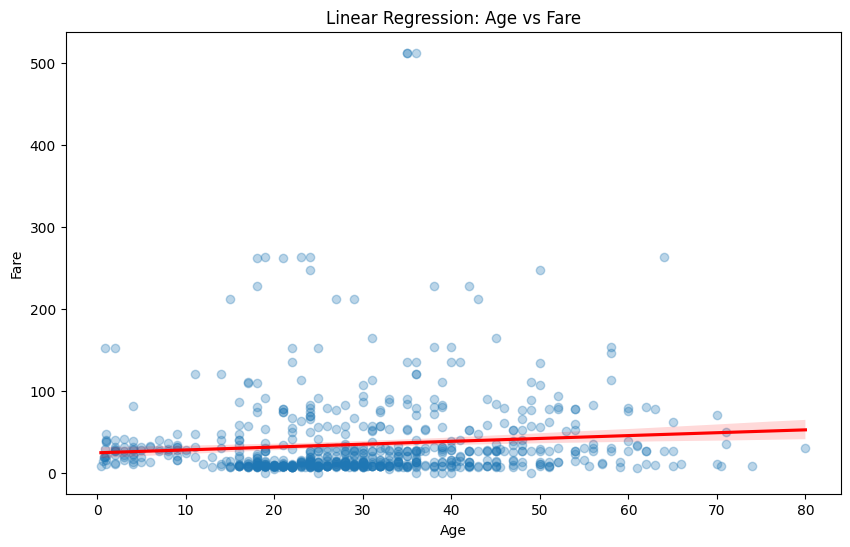

In [ ]:
# Drop missing values for regression
regression_data = df[['Age', 'Fare']].dropna()
X = regression_data['Age']
y = regression_data['Fare']

# Add constant for intercept
X_const = sm.add_constant(X)

# Fit the model
model_lr = sm.OLS(y, X_const).fit()

# Display summary
print(model_lr.summary())

# Visualize the regression line
plt.figure(figsize=(10, 6))
sns.regplot(x='Age', y='Fare', data=regression_data, line_kws={'color':'red'}, scatter_kws={'alpha':0.3})
plt.title('Linear Regression: Age vs Fare')
plt.show()